# Détection des zones de sous-desserte (Clustering)

**Problématique** : Détecter les zones de sous-desserte ou fragiles — identification non-supervisée de groupes de relations à risque.

**Objectif** : Regrouper les relations ferroviaires en clusters homogènes, puis analyser si ces clusters correspondent aux types de desserte connus.

> Le clustering est non-supervisé : il ignore le `desserte_type` à l'entraînement. On l'utilise ensuite pour validation et pour détecter des sous-groupes imprévus.

## Imports & Configuration

In [80]:
#!pip install numpy pandas matplotlib seaborn scikit-learn joblib

In [81]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, homogeneity_score,
    completeness_score, v_measure_score
)
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
)
from sklearn.mixture import GaussianMixture

In [82]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
CLUSTER_PALETTE = ['#d62728','#1f77b4','#2ca02c','#ff7f0e','#9467bd','#8c564b']

## Chargement des données

In [83]:
INPUT_FOLDER = "../../../data/output"

csv_files = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))
print(f"Fichiers trouvés : {[os.path.basename(f) for f in csv_files]}")

dfs = []
for filepath in csv_files:
    df_tmp = pd.read_csv(filepath)
    print(f"{os.path.basename(filepath)} — {len(df_tmp)} lignes")
    dfs.append(df_tmp)

df_raw = pd.concat(dfs, ignore_index=True)

print(f"\n Dataset combiné : {df_raw.shape[0]} lignes et {df_raw.shape[1]} colonnes")
df_raw.head()

Fichiers trouvés : ['austria_etl.csv', 'germany_etl.csv', 'spain_etl.csv']
austria_etl.csv — 3683 lignes
germany_etl.csv — 876 lignes
spain_etl.csv — 680 lignes

 Dataset combiné : 5239 lignes et 6 colonnes


,data_source,route_id,id_origin_city,id_destination_city,weekly_train,desserte_type
0,austria,1-80-j26-1,at:49:1349:0:10,at:43:4132:0:1,1,Sous-desservi
1,austria,1-MB4-j26-1,at:48:130:0:12,at:48:134:0:8,37,Desserte Normale
2,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:1,1,Sous-desservi
3,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:10,3,Sous-desservi
4,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:4,37,Desserte Normale


## Préparation des features

In [84]:
df = df_raw.copy()

FEATURES = ['data_source', 'route_id', 'id_origin_city', 'id_destination_city', 'weekly_train']
TARGET   = 'desserte_type'

# Encodage des variables catégorielles
for col in ['data_source', 'route_id', 'id_origin_city', 'id_destination_city']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Encodage de la target (utilisée uniquement pour validation externe)
le_target = LabelEncoder()
y_true = le_target.fit_transform(df[TARGET])
class_names = le_target.classes_
print("Classes cibles :", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

FEATURE_COLS = ['data_source_enc', 'route_id_enc', 'id_origin_city_enc',
                'id_destination_city_enc', 'weekly_train']

X_raw = df[FEATURE_COLS].values

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"\nFeatures prêtes : {X.shape}")

Classes cibles : {'Bien desservi': np.int64(0), 'Desserte Normale': np.int64(1), 'Sous-desservi': np.int64(2)}

Features prêtes : (5239, 5)


## nombre optimal de clusters (K)

Méthodes : Elbow (inertie), Silhouette score

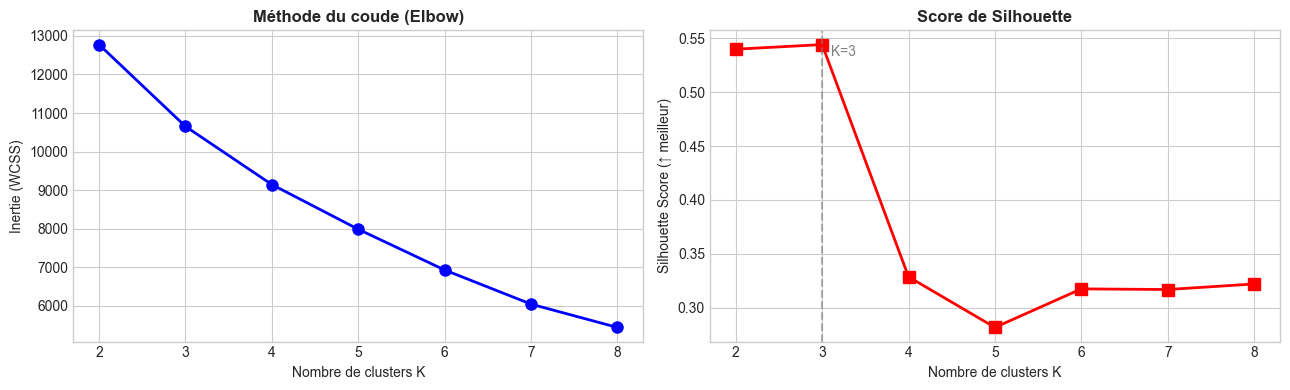


 K optimal suggéré par Silhouette : K = 3


In [85]:
K_RANGE = range(2, 9)
inertias   = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Méthode du coude (Elbow)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')

axes[1].plot(K_RANGE, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Score de Silhouette', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score (↑ meilleur)')

best_k = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='gray', linestyle='--', alpha=0.6)
axes[1].text(best_k + 0.1, max(silhouettes)*0.98, f'K={best_k}', color='gray')

plt.tight_layout()
plt.show()
print(f"\n K optimal suggéré par Silhouette : K = {best_k}")

In [86]:
N_CLUSTERS = best_k
print(f"K retenu pour l'entraînement : {N_CLUSTERS}")

K retenu pour l'entraînement : 3


## Entraînement & Comparaison des algorithmes de clustering

Algorithmes testés :
- **KMeans** : référence, clusters sphériques
- **DBSCAN** : détecte les outliers, nombre de clusters automatique

In [87]:
algorithms = {
    'KMeans'                : KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=15),
    'DBSCAN (auto-K)'       : DBSCAN(eps=1.0, min_samples=10, n_jobs=-1),
}

results    = []
all_labels = {}

for name, algo in algorithms.items():
    if hasattr(algo, 'fit_predict'):
        labels = algo.fit_predict(X)
    else:
        labels = algo.fit(X).predict(X)

    all_labels[name] = labels
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise          = list(labels).count(-1)

    # Métriques internes
    valid_mask = labels != -1
    if n_clusters_found >= 2 and valid_mask.sum() > 0:
        sil = silhouette_score(X[valid_mask], labels[valid_mask])
        db  = davies_bouldin_score(X[valid_mask], labels[valid_mask])
        ch  = calinski_harabasz_score(X[valid_mask], labels[valid_mask])
    else:
        sil = db = ch = np.nan

    # Métriques externes
    ari  = adjusted_rand_score(y_true[valid_mask], labels[valid_mask])
    nmi  = normalized_mutual_info_score(y_true[valid_mask], labels[valid_mask])
    homo = homogeneity_score(y_true[valid_mask], labels[valid_mask])
    comp = completeness_score(y_true[valid_mask], labels[valid_mask])
    vmes = v_measure_score(y_true[valid_mask], labels[valid_mask])

    results.append({
        'Algorithme'           : name,
        'K trouvé'             : n_clusters_found,
        'Bruit (points)'       : n_noise,
        # Métriques internes
        'Silhouette'         : sil,
        # Métriques externes 
        'ARI' : ari,
        'V-Measure' : vmes,
    })
    print(f"{name} : K={n_clusters_found}, Silhouette={sil:.3f}, ARI={ari:.3f}")

df_results = pd.DataFrame(results).set_index('Algorithme')

KMeans : K=3, Silhouette=0.544, ARI=0.108
DBSCAN (auto-K) : K=4, Silhouette=0.465, ARI=0.097


## Tableaux de métriques

In [88]:
pd.set_option('display.float_format', '{:.4f}'.format)

print("Métriques INTERNES")
internal = df_results[['K trouvé', 'Bruit (points)', 'Silhouette']]
styled_internal = internal.style\
    .background_gradient(cmap='RdYlGn', subset=['Silhouette'])\
    .format('{:.4f}', subset='Silhouette')\
    .set_caption('Métriques internes')
styled_internal

Métriques INTERNES


,K trouvé,Bruit (points),Silhouette
Algorithme,,,
KMeans,3,0,0.5443
DBSCAN (auto-K),4,46,0.4647


In [89]:
print("Métriques EXTERNES")
external = df_results[['ARI', 'V-Measure']]
styled_external = external.style\
    .background_gradient(cmap='RdYlGn')\
    .format('{:.4f}')\
    .set_caption('Métriques externes')
styled_external

Métriques EXTERNES


,ARI,V-Measure
Algorithme,,
KMeans,0.1080,0.0903
DBSCAN (auto-K),0.0969,0.0280


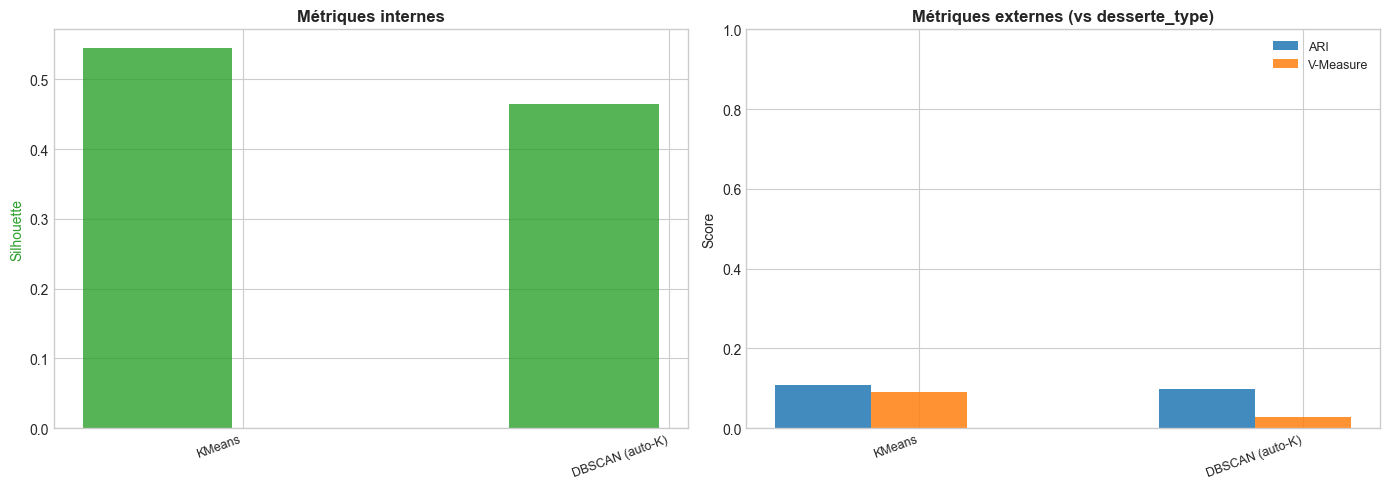

In [90]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métriques internes
metrics_int = 'Silhouette'
x = np.arange(len(df_results))
labels_x = df_results.index.tolist()

ax = axes[0]
bars = ax.bar(x - 0.2, df_results['Silhouette'], 0.35, label='Silhouette', color='#2ca02c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_x, rotation=20, ha='right', fontsize=9)
ax.set_title('Métriques internes', fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette', color='#2ca02c')

# Métriques externes
ax = axes[1]
ext_metrics = ['ARI', 'V-Measure']
width = 0.25
colors_ext = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (m, c) in enumerate(zip(ext_metrics, colors_ext)):
    offset = (i - 1) * width
    ax.bar(x + offset, df_results[m], width, label=m, color=c, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_x, rotation=20, ha='right', fontsize=9)
ax.set_title('Métriques externes (vs desserte_type)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Meilleur algorithme, Visualisation & Profiling

In [91]:
# Sélection sur Silhouette (métrique interne robuste)
best_algo_name = df_results['Silhouette'].idxmax()
best_labels    = all_labels[best_algo_name]
print(f"Meilleur algorithme : {best_algo_name}")
print(f"Silhouette = {df_results.loc[best_algo_name, 'Silhouette']:.4f}")
print(f"ARI = {df_results.loc[best_algo_name, 'ARI']:.4f}")

Meilleur algorithme : KMeans
Silhouette = 0.5443
ARI = 0.1080


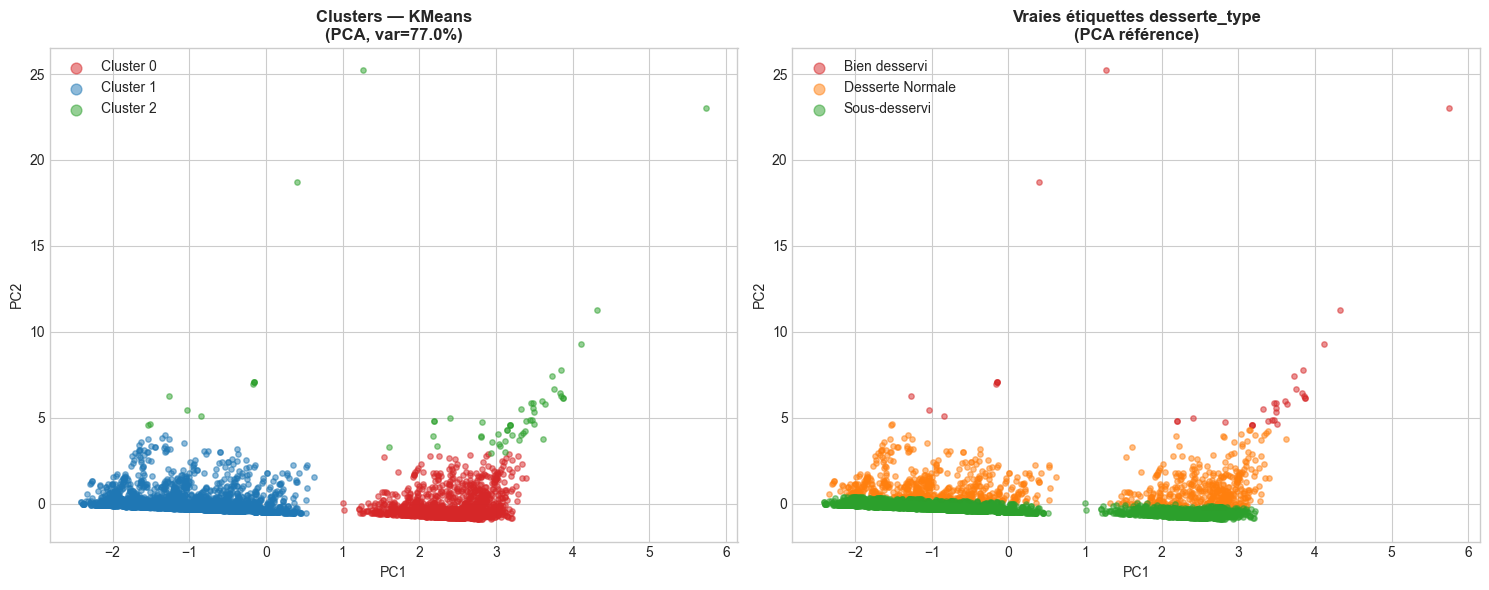

In [96]:
# Réduction dimensionnelle PCA pour visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Clusters trouvés
ax = axes[0]
unique_clusters = sorted(set(best_labels))
for i, cl in enumerate(unique_clusters):
    mask = best_labels == cl
    lbl  = f'Cluster {cl}' if cl != -1 else 'Bruit'
    col  = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] if cl != -1 else 'lightgray'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=col, label=lbl, alpha=0.5, s=15)
ax.set_title(f'Clusters — {best_algo_name}\n(PCA, var={var_explained:.1%})', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2)

# Vraies étiquettes (desserte_type) pour comparaison
ax = axes[1]
colors_true = ['#d62728','#ff7f0e','#2ca02c']
for i, cls in enumerate(class_names):
    mask = y_true == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_true[i], label=cls, alpha=0.5, s=15)
ax.set_title('Vraies étiquettes desserte_type\n(PCA référence)', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2)

plt.tight_layout()
plt.show()

In [93]:
# Profil de chaque cluster
df_profile = df.copy()
df_profile['cluster'] = best_labels

print("Profil des clusters (statistiques descriptives)")
profile = df_profile.groupby('cluster').agg(
    nb_relations       = ('weekly_train', 'count'),
    weekly_train_mean  = ('weekly_train', 'mean'),
    weekly_train_median= ('weekly_train', 'median'),
    weekly_train_std   = ('weekly_train', 'std'),
).round(2)
print(profile)

print("\n Composition des clusters vs desserte_type")
cross = pd.crosstab(df_profile['cluster'], df_profile['desserte_type'], normalize='index').round(3)
print(cross)

Profil des clusters (statistiques descriptives)
         nb_relations  weekly_train_mean  weekly_train_median  \
cluster                                                         
0                1508             6.2700               3.0000   
1                3672             3.8400               2.0000   
2                  59            71.3200              59.0000   

         weekly_train_std  
cluster                    
0                  7.3200  
1                  5.6600  
2                 43.1800  

 Composition des clusters vs desserte_type
desserte_type  Bien desservi  Desserte Normale  Sous-desservi
cluster                                                      
0                     0.0000            0.2840         0.7160
1                     0.0000            0.1470         0.8530
2                     0.6270            0.3730         0.0000


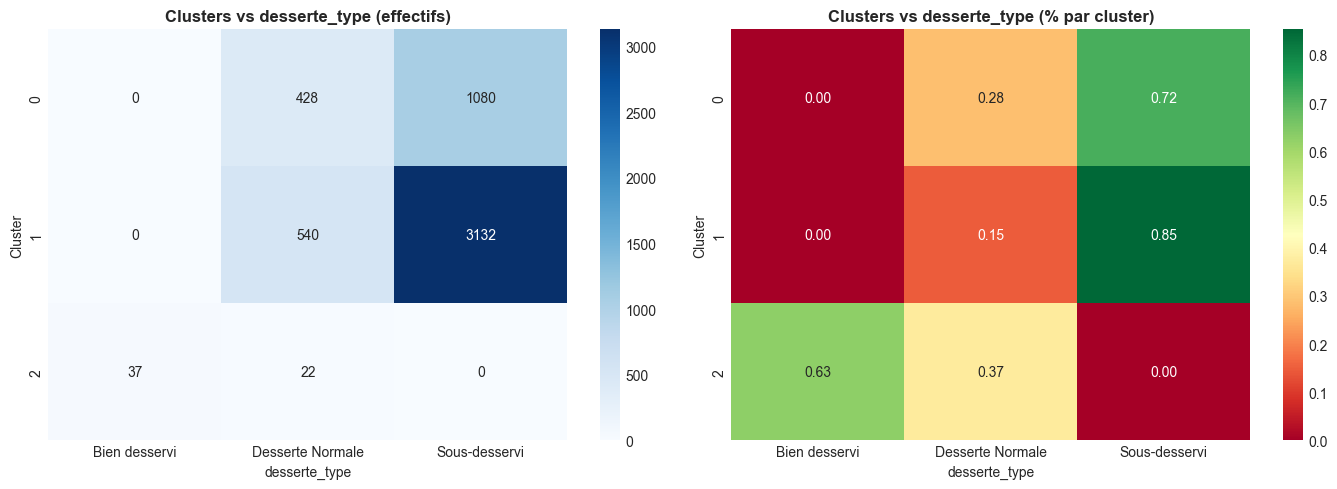

In [94]:
# Heatmap clusters vs desserte_type
cross_counts = pd.crosstab(df_profile['cluster'], df_profile['desserte_type'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cross_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Clusters vs desserte_type (effectifs)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cluster')

cross_pct = pd.crosstab(df_profile['cluster'], df_profile['desserte_type'], normalize='index').round(3)
sns.heatmap(cross_pct, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Clusters vs desserte_type (% par cluster)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cluster')

plt.tight_layout()
plt.show()

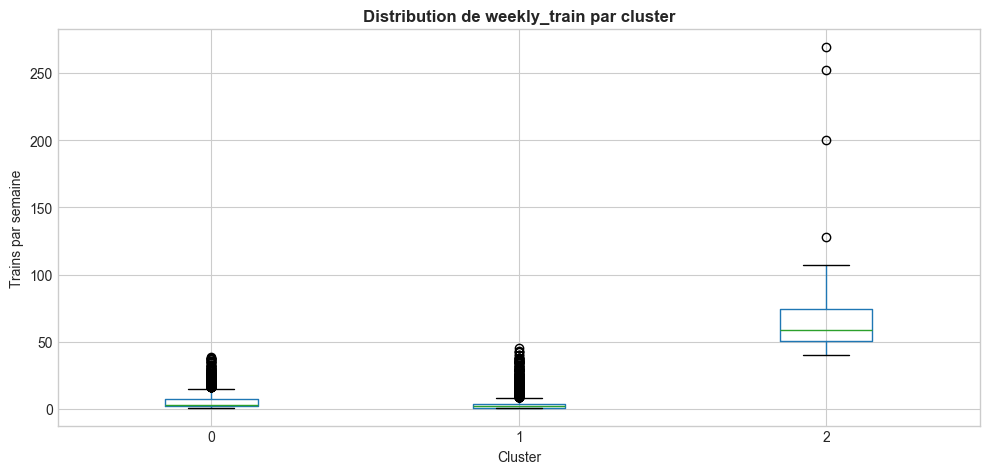

In [95]:
# Boxplot weekly_train par cluster
fig, ax = plt.subplots(figsize=(10, 5))
df_profile[df_profile['cluster'] != -1].boxplot(
    column='weekly_train', by='cluster', ax=ax
)
ax.set_title('Distribution de weekly_train par cluster', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Trains par semaine')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Export des résultats